<a href="https://colab.research.google.com/github/ArkanUbaidillah/Arkan-Ubaidillah-Warman_2411537001_ML2526/blob/main/Praktikum6/DecisionBoundaryVisualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


In [5]:
dataset_url = 'https://raw.githubusercontent.com/ArkanUbaidillah/Arkan-Ubaidillah-Warman_2411537001_ML2526/refs/heads/main/Praktikum2/Breast_cancer_data_cae7db121c99c2dfb709598afde3ccfe.csv'
data = pd.read_csv(dataset_url)
data.head()

# Kesalahan: 'data' adalah DataFrame, bukan objek Bunch dari sklearn.datasets.
# DataFrame tidak memiliki atribut '.data' atau '.feature_names'.
# Fitur (X) adalah semua kolom kecuali kolom terakhir.
# Target (y) adalah kolom terakhir.
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Ambil 2 fitur saja untuk visualisasi
X = X[['mean_radius', 'mean_texture']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [7]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))


KNN Accuracy: 0.9035087719298246


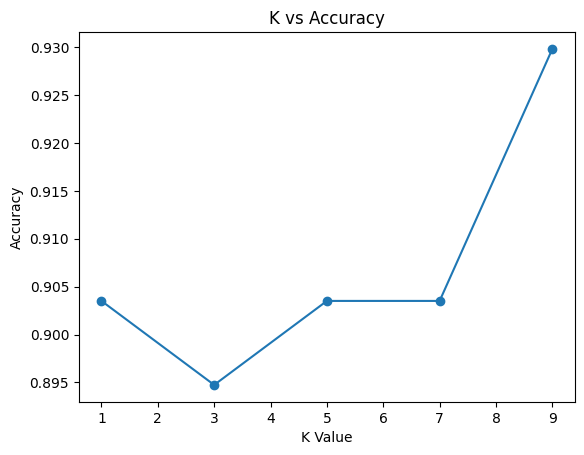

In [8]:
k_values = [1, 3, 5, 7, 9]
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()


In [9]:
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_scaled, y_train)

y_pred_svm_linear = svm_linear.predict(X_test_scaled)

print("SVM Linear Accuracy:", accuracy_score(y_test, y_pred_svm_linear))


SVM Linear Accuracy: 0.9035087719298246


In [10]:
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_scaled, y_train)

y_pred_svm_rbf = svm_rbf.predict(X_test_scaled)

print("SVM RBF Accuracy:", accuracy_score(y_test, y_pred_svm_rbf))


SVM RBF Accuracy: 0.9210526315789473


In [11]:
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')
    plt.title(title)
    plt.show()


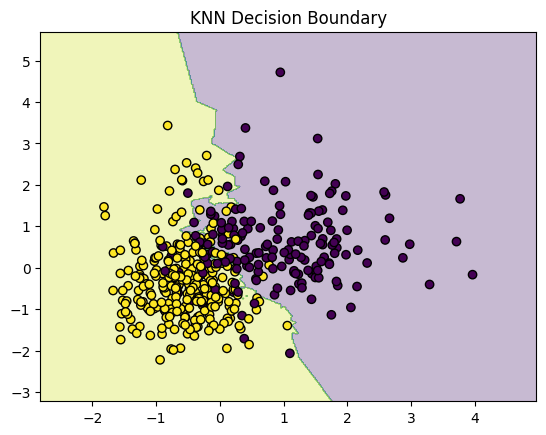

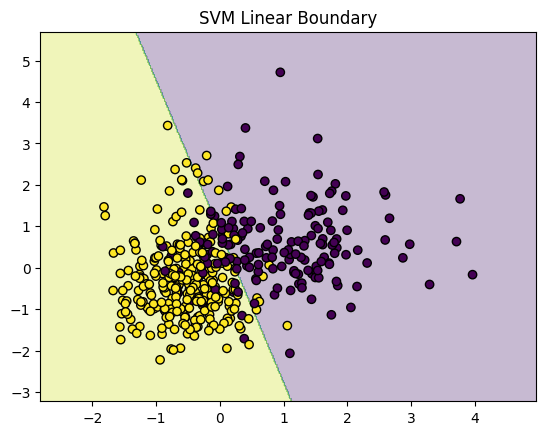

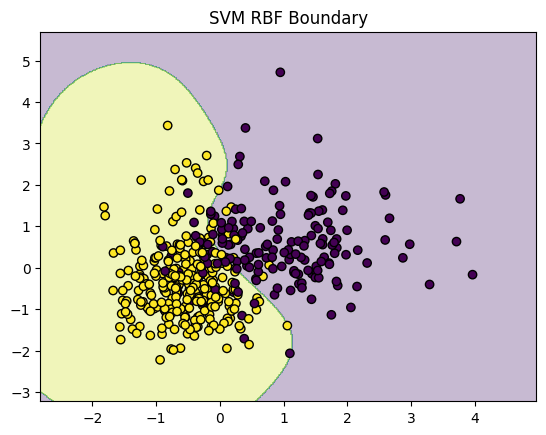

In [12]:
plot_decision_boundary(knn, X_train_scaled, y_train, "KNN Decision Boundary")
plot_decision_boundary(svm_linear, X_train_scaled, y_train, "SVM Linear Boundary")
plot_decision_boundary(svm_rbf, X_train_scaled, y_train, "SVM RBF Boundary")


TUGAS INDIVIDU

In [13]:
knn_no_scaling = KNeighborsClassifier(n_neighbors=5)
knn_no_scaling.fit(X_train, y_train)

y_pred_no_scaling = knn_no_scaling.predict(X_test)
print("KNN tanpa scaling:", accuracy_score(y_test, y_pred_no_scaling))

KNN tanpa scaling: 0.9035087719298246


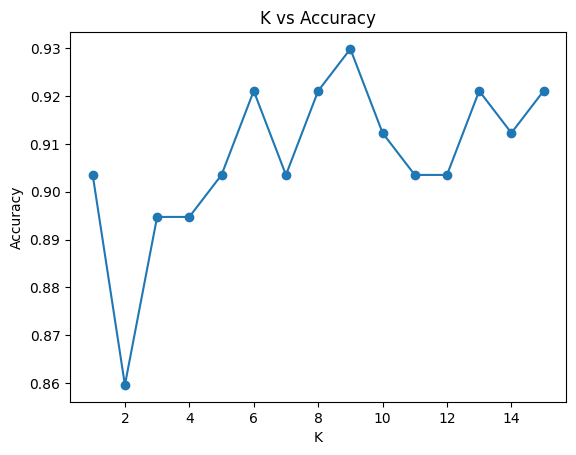

In [14]:
k_range = range(1, 16)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    scores.append(accuracy_score(y_test, y_pred))

plt.plot(k_range, scores, marker='o')
plt.title("K vs Accuracy")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

In [15]:
for C in [0.1, 1, 10]:
    for gamma in ['scale', 'auto']:
        model = SVC(kernel='rbf', C=C, gamma=gamma)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        print(f"C={C}, gamma={gamma}, acc={accuracy_score(y_test, y_pred)}")

C=0.1, gamma=scale, acc=0.9035087719298246
C=0.1, gamma=auto, acc=0.9035087719298246
C=1, gamma=scale, acc=0.9210526315789473
C=1, gamma=auto, acc=0.9210526315789473
C=10, gamma=scale, acc=0.9122807017543859
C=10, gamma=auto, acc=0.9122807017543859


In [16]:
from sklearn.model_selection import cross_val_score

models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM Linear": SVC(kernel='linear'),
    "SVM RBF": SVC(kernel='rbf')
}

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    print(name, "Mean Accuracy:", scores.mean())

KNN Mean Accuracy: 0.8747252747252748
SVM Linear Mean Accuracy: 0.8835164835164836
SVM RBF Mean Accuracy: 0.8989010989010989
